In [4]:
import torch
print(torch.cuda.is_available())
print(torch.__version__)
!nvcc --version

True
1.11.0
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Mon_May__3_19:15:13_PDT_2021
Cuda compilation tools, release 11.3, V11.3.109
Build cuda_11.3.r11.3/compiler.29920130_0


In [5]:
!wget -O simhei.ttf "https://www.wfonts.com/download/data/2014/06/01/simhei/chinese.simhei.ttf"
import matplotlib.pyplot as plt
import matplotlib as mpl
zhfont = mpl.font_manager.FontProperties(fname='simhei.ttf')
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

--2022-10-18 11:24:43--  https://www.wfonts.com/download/data/2014/06/01/simhei/chinese.simhei.ttf
Resolving www.wfonts.com (www.wfonts.com)... 104.225.219.210
Connecting to www.wfonts.com (www.wfonts.com)|104.225.219.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10050870 (9.6M) [application/octetstream]
Saving to: ‘simhei.ttf’

simhei.ttf          100%[===================>]   9.58M   629KB/s    in 20s     

2022-10-18 11:25:05 (484 KB/s) - ‘simhei.ttf’ saved [10050870/10050870]



In [2]:
# ETTh1_48_48_24
!python -u main_informer.py --model informer --data ETTh1 --features S --seq_len 48 --label_len 48 --pred_len 24 --e_layers 2 --d_layers 1 --attn prob --des 'Exp' --itr 1 --factor 3 --scaler_way 1 --inverse

Args in experiment:
Namespace(activation='gelu', attn='prob', batch_size=32, c_out=1, checkpoints='./checkpoints/', cols=None, d_ff=2048, d_layers=1, d_model=512, data='ETTh1', data_path='ETTh1.csv', dec_in=1, des='Exp', detail_freq='h', devices='0,1,2,3', distil=True, do_predict=False, dropout=0.05, e_layers=2, embed='timeF', enc_in=1, factor=3, features='S', freq='h', gpu=0, inverse=True, itr=1, label_len=48, learning_rate=0.0001, loss='mse', lradj='type1', mix=True, model='informer', n_heads=8, num_workers=0, output_attention=False, padding=0, patience=3, pred_len=24, root_path='./data/ETT/', s_layers=[3, 2, 1], scaler_way=1, seq_len=48, target='OT', train_epochs=6, use_amp=False, use_gpu=True, use_multi_gpu=False)
Use GPU: cuda:0
>>>>>>>start training : informer_ETTh1_ftS_sl48_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc3_ebtimeF_dtTrue_mxTrue_Exp_0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 8569
val 2857
test 2857
	iters: 100, epoch: 1 | loss: 31.8724747
	speed: 0.1100s/iter; left time: 165.

In [3]:
#打印结果
import numpy as np

setting = "informer_ETTh1_ftS_sl48_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc3_ebtimeF_dtTrue_mxTrue_Exp_0"
np.set_printoptions(precision=3) #设置小数位置为3位

input = np.load('./results/'+setting+'/input.npy')
print("输入的数据为：{}".format(input[0,:,0]))

pred = np.load('./results/'+setting+'/pred.npy')
print("预测的结果为：{}".format(pred[0,:,0]))

true = np.load('./results/'+setting+'/true.npy')
print("真实的结果为：{}".format(true[0,:,0]))

metrics = np.load('./results/'+setting+'/metrics.npy')
print("mae, mse, rmse, mape, mspe分别为：{}".format(metrics))

输入的数据为：[ 9.778  9.778  9.708  9.919  9.426  8.934  9.638  8.09   8.582  9.638
 10.904 10.974 11.396 12.522 12.874 12.381 13.647 13.436 12.1   11.959
 12.029 11.537 11.537 10.904 10.763 11.256 11.889 12.381 11.326 10.622
  9.497  9.215  9.426  9.356 10.763 11.044 11.256 11.256 11.396 11.185
 11.326 11.467 10.552 10.271  9.708  8.723  8.864  9.004]
预测的结果为：[5.523 5.45  5.377 5.314 5.068 4.852 3.886 4.652 5.398 5.326 6.878 5.101
 6.155 5.837 5.816 7.325 6.686 6.996 7.041 7.874 7.012 6.807 6.743 6.887]
真实的结果为：[ 9.215  9.145  9.497  9.075  8.723  8.934  8.864  8.864  9.426  9.426
  9.708  9.849 10.06  11.678 12.17  11.185 11.044 11.607 10.974 11.396
 10.833 10.833 10.341  9.286]
mae, mse, rmse, mape, mspe分别为：[1.656 4.5   2.121   inf   inf]


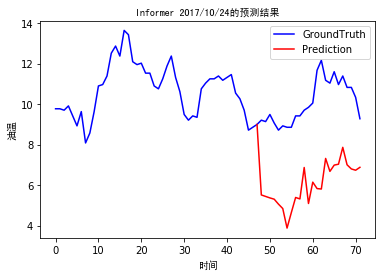

In [6]:
#画图
x1 = np.arange(72)
x2 = np.arange(47,72)
y_t = np.concatenate((input[0,:,0],true[0,:,0]))
y_p = np.concatenate(([input[0,-1,0]],pred[0,:,0]))

plt.plot(x1,y_t,color='b')
plt.plot(x2,y_p,color='r')
plt.xlabel(u'时间',fontproperties=zhfont)
plt.ylabel(u'油温',fontproperties=zhfont)
plt.legend(('GroundTruth', 'Prediction'), loc='upper right')
plt.title(u'Informer 2017/10/24的预测结果',fontproperties=zhfont)

plt.savefig('./Informer_ETTh1_S_48_48_24.png')
plt.show()